In [3]:
from pyfiles.ftsteane import *
from HPC.Upload.classes import *
from random import choices
import cirq
import itertools
import textwrap


plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Bitstream Vera Sans",
    "font.sans-serif": "Helvetica",
})

[0.    0.001 0.002 0.003 0.004 0.005] [0.00285714 0.11013393 0.14522321 0.17741071 0.18549107 0.20116071] [0.00196429 0.08839286 0.13589286 0.1625     0.17950893 0.19723214] [0.00053153 0.00281065 0.00282134 0.00322985 0.00289558 0.00305075] [0.00041678 0.00263544 0.00274369 0.00275487 0.00303371 0.00302558]


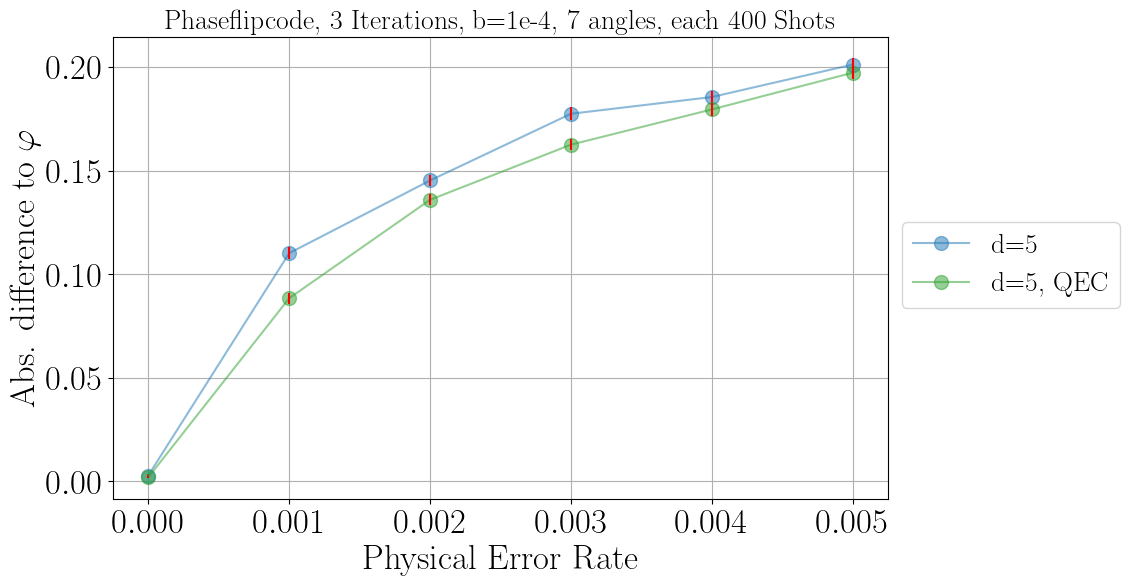

In [ ]:
shots = 400
p, y, y_qec, err, err_qec = np.loadtxt("HPC/text/d5_Repcodez_smaller.txt", delimiter = ",")                 #NEU MACHEN

print(p, y, y_qec, err, err_qec)

fig, ax1 = plt.subplots(figsize=(10,6))

try:
    colors = plt.cm.viridis(np.linspace(0, 1, len(p)))
except TypeError:
    pass

ax1.plot(p,y, label="d=5", marker = ".",markersize = 20, alpha = 0.5)
ax1.errorbar(p, y, yerr=err, ecolor="red", linestyle="")

ax1.plot(p,y_qec, label="d=5, QEC", marker = ".",markersize = 20, alpha = 0.5)
ax1.errorbar(p, y_qec, yerr=err_qec, ecolor="red", linestyle="")

#################### ####################

ax1.set_title(r"Phaseflipcode, 3 Iterations, b=-1e4, 7 angles, each {} Shots".format(int(shots)), fontsize=20)
ax1.set_xlabel("Physical Error Rate", fontsize=25)
ax1.set_ylabel(r"Abs. difference to $\varphi$", fontsize=25)
ax1.tick_params(axis='both', which='major', labelsize=25)
ax1.grid()
fig.legend(loc="center left", bbox_to_anchor=(0.9, 0.5), fontsize=20)# ax1.legend(fontsize=20)


#plt.tight_layout()
# plt.savefig("14.png", bbox_inches="tight" ,dpi=200)
plt.show()

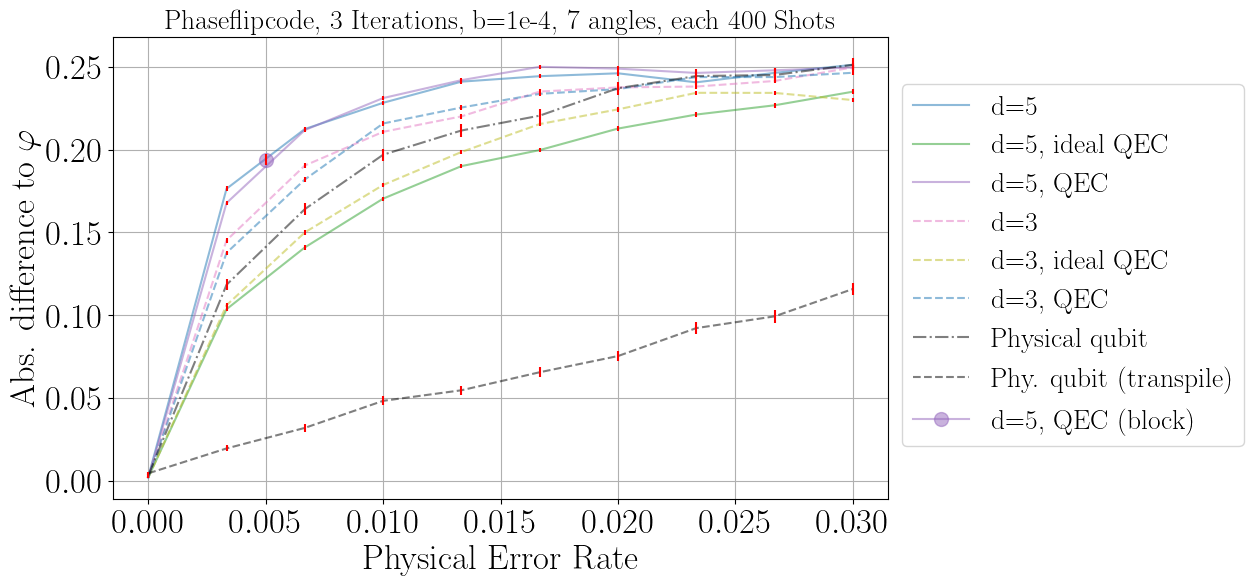

In [ ]:
shots = 400
p, y, y_qec, err, err_qec = np.loadtxt("HPC/text/d5_Repcodez_ideal.txt", delimiter = ",")               #NEU MACHEN
y, y_qec = [i*(15/7) for i in y], [i*(15/7) for i in y_qec]

p1, y1, y_qec1, err1, err_qec1 = np.loadtxt("HPC/text/d3_Repcodez_ideal.txt", delimiter = ",")                  #NEU MACHEN
y1, y_qec1 = [i*(15/7) for i in y1], [i*(15/7) for i in y_qec1]

p2, y2, y_qec2, err2, err_qec2 = np.loadtxt("HPC/text/d3_Repcodez.txt", delimiter = ",")                        #NEU MACHEN
y2, y_qec2 = [i*(15/7) for i in y2], [i*(15/7) for i in y_qec2]

p3, y3, err3 = np.loadtxt("HPC/text/physicalq.txt", delimiter = ",")

p3_t, y3_t, err3_t = np.loadtxt("HPC/text/physicalq_transpile.txt", delimiter = ",")

p4, y4, y_qec4, err4, err_qec4 = np.loadtxt("HPC/text/d5_Repcodez.txt", delimiter = ",")                    #NEU MACHEN

p5, y5, y_qec5, err5, err_qec5 = np.loadtxt("HPC/text/d5_Repcodez_block_0_.txt", delimiter = ",")               #NEU MACHEN

# err, err_qec = [i/np.sqrt(shots) for i in err], [i/np.sqrt(shots) for i in err_qec]

fig, ax1 = plt.subplots(figsize=(10,6))

colors = plt.cm.viridis(np.linspace(0, 1, len(p)))

ax1.plot(p,y, label="d=5", marker = "",markersize = 20, alpha = 0.5)
ax1.errorbar(p, y, yerr=err, ecolor="red", linestyle="")

ax1.plot(p,y_qec, label="d=5, ideal QEC", marker = "",markersize = 20, alpha = 0.5)
ax1.errorbar(p, y_qec, yerr=err_qec, ecolor="red", linestyle="")

ax1.plot(p4,y_qec4, label="d=5, QEC", marker = "",markersize = 20, alpha = 0.5)
ax1.errorbar(p4, y_qec4, yerr=err_qec, ecolor="red", linestyle="")

ax1.plot(p1,y1, label="d=3", marker = "",markersize = 20, alpha = 0.5, linestyle="--")
ax1.errorbar(p1, y1, yerr=err, ecolor="red", linestyle="")

ax1.plot(p1,y_qec1, label="d=3, ideal QEC", marker = "",markersize = 20, alpha = 0.5, linestyle="--")
ax1.errorbar(p1, y_qec1, yerr=err_qec, ecolor="red", linestyle="")

# ax1.plot(p2,y2, label="d=3, No QEC", marker = "",markersize = 20, alpha = 0.5, linestyle="--")
# ax1.errorbar(p2, y_qec2, yerr=err_qec, ecolor="red", linestyle="")

ax1.plot(p2,y_qec2, label="d=3, QEC", marker = "",markersize = 20, alpha = 0.5, linestyle="--")
ax1.errorbar(p2, y_qec2, yerr=err_qec, ecolor="red", linestyle="")

ax1.plot(p3, y3, label="Physical qubit", marker = "",markersize = 20, alpha = 0.5, linestyle="-.", color="black")
ax1.errorbar(p3, y3, yerr=err3, ecolor="red", linestyle="")

ax1.plot(p3_t, y3_t, label="Phy. qubit (transpile)", marker = "",markersize = 20, alpha = 0.5, linestyle="--", color="black")
ax1.errorbar(p3_t, y3_t, yerr=err3_t, ecolor="red", linestyle="")

#################### QEC 5 Block + MWPM decoder ####################

# ax1.plot(p5, y5, label="d=5", marker = ".",markersize = 20, alpha = 0.5)
# ax1.errorbar(p5, y5, yerr=err5, ecolor="red", linestyle="")

ax1.plot(p5, y_qec5, label="d=5, QEC (block)", marker = ".",markersize = 20, alpha = 0.5)
ax1.errorbar(p5, y_qec5, yerr=err_qec5, ecolor="red", linestyle="")

#################### ####################

ax1.set_title(r"Phaseflipcode, 3 Iterations, b=-1e4, 7 angles, each {} Shots".format(int(shots)), fontsize=20)
ax1.set_xlabel("Physical Error Rate", fontsize=25)
ax1.set_ylabel(r"Abs. difference to $\varphi$", fontsize=25)
ax1.tick_params(axis='both', which='major', labelsize=25)
ax1.grid()
fig.legend(loc="center left", bbox_to_anchor=(0.9, 0.5), fontsize=20)# ax1.legend(fontsize=20)


#plt.tight_layout()
# plt.savefig("14.png", bbox_inches="tight" ,dpi=200)
plt.show()

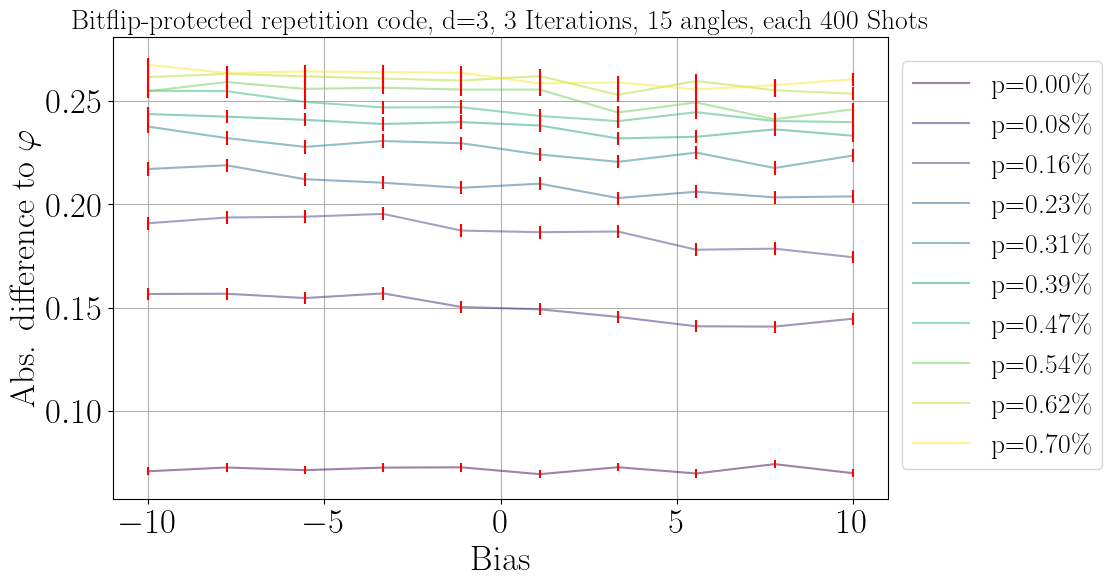

In [2]:
shots = 400
data = np.load("HPC/text/Repcode_d3.npy")

p = np.linspace(0,0.007,10)

fig, ax1 = plt.subplots(figsize=(10,6))

colors = plt.cm.viridis(np.linspace(0, 1, len(p)))

for i,layer in enumerate(data):
    bias, y, y_qec, err, err_qec = layer[0], layer[1], layer[2], layer[3], layer[4]
    ax1.plot(bias, y, label=r"p={:.2f}\%".format(100*p[i]), marker = "",markersize = 20, alpha = 0.5, color=colors[i])
    #ax1.plot(bias, y_qec, label=r"p={:.2f}\%, QEC".format(100*p[i]), marker = "",markersize = 20, alpha = 0.5, color=colors[i], linestyle=":")
    ax1.errorbar(bias, y, yerr=err, ecolor="red", linestyle="")
   #ax1.errorbar(bias, y_qec, yerr=err_qec, ecolor="red", linestyle="")

ax1.set_title(r"Bitflip-protected repetition code, d=3, 3 Iterations, 15 angles, each {} Shots".format(int(shots)), fontsize=20)
ax1.set_xlabel("Bias", fontsize=25)
ax1.set_ylabel(r"Abs. difference to $\varphi$", fontsize=25)
ax1.tick_params(axis='both', which='major', labelsize=25)
ax1.grid()
fig.legend(loc="center left", bbox_to_anchor=(0.9, 0.5), fontsize=20)# ax1.legend(fontsize=20)


#plt.tight_layout()
plt.savefig("repcode_d9_bias.png", bbox_inches="tight" ,dpi=200)
plt.show()

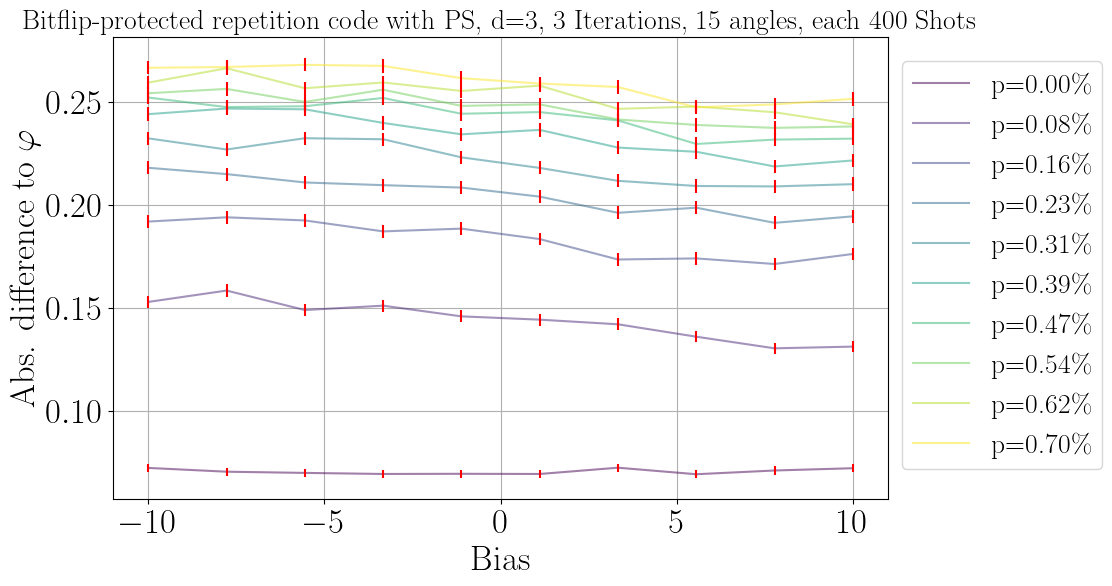

In [3]:
shots = 400
data = np.load("HPC/text/Repcode_d3_post.npy")

p = np.linspace(0,0.007,10)

fig, ax1 = plt.subplots(figsize=(10,6))

colors = plt.cm.viridis(np.linspace(0, 1, len(p)))

for i,layer in enumerate(data):
    bias, y, y_qec, err, err_qec = layer[0], layer[1], layer[2], layer[3], layer[4]
    ax1.plot(bias, y, label=r"p={:.2f}\%".format(100*p[i]), marker = "",markersize = 20, alpha = 0.5, color=colors[i])
    #ax1.plot(bias, y_qec, label=r"p={:.2f}\%, QEC".format(100*p[i]), marker = "",markersize = 20, alpha = 0.5, color=colors[i], linestyle=":")
    ax1.errorbar(bias, y, yerr=err, ecolor="red", linestyle="")
    #ax1.errorbar(bias, y_qec, yerr=err_qec, ecolor="red", linestyle="")

ax1.set_title(r"Bitflip-protected repetition code with PS, d=3, 3 Iterations, 15 angles, each {} Shots".format(int(shots)), fontsize=20)
ax1.set_xlabel("Bias", fontsize=25)
ax1.set_ylabel(r"Abs. difference to $\varphi$", fontsize=25)
ax1.tick_params(axis='both', which='major', labelsize=25)
ax1.grid()
fig.legend(loc="center left", bbox_to_anchor=(0.9, 0.5), fontsize=20)# ax1.legend(fontsize=20)


#plt.tight_layout()
plt.savefig("repcode_d9_bias.png", bbox_inches="tight" ,dpi=200)
plt.show()

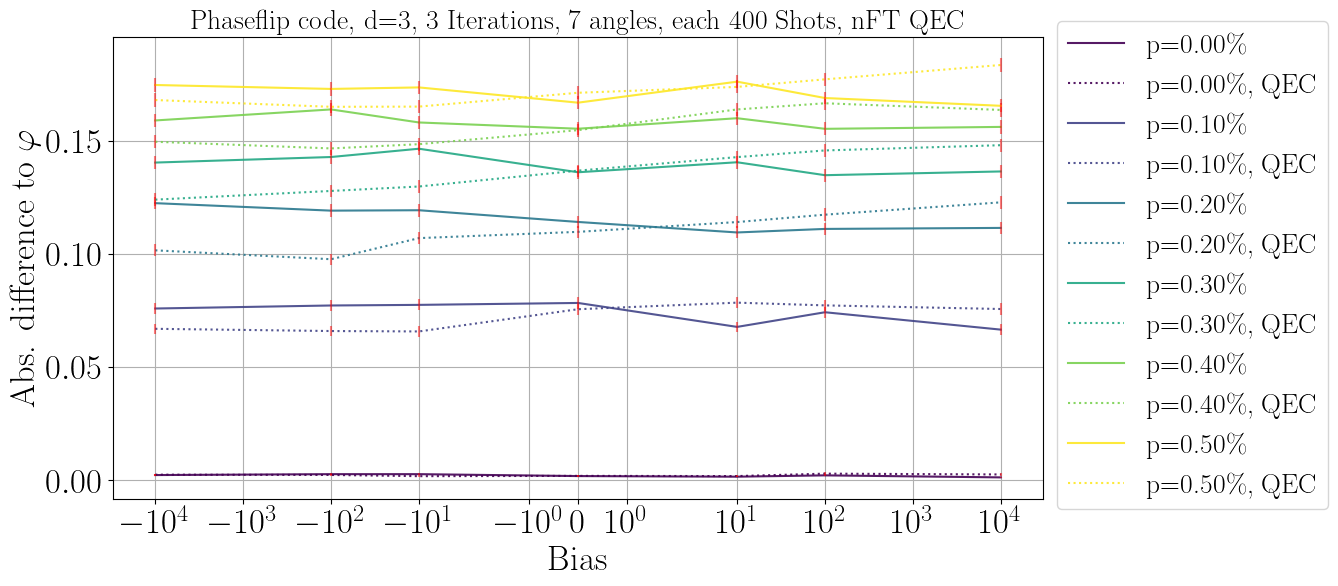

In [9]:
shots, angles = 400, 7
# data, p = np.load("HPC/text/Repcodez_d3_qec.npy"), np.linspace(0.00,0.01,10)                     #np.linspace(0.00,0.01,10)          ; alte lange circuits mit HTHTdgH..., ohne t_x, s_x, ...
# data, p = np.load("HPC/text/Repcodez_d3_idealqec.npy"), np.linspace(0.00,0.005,5)              #np.linspace(0.00,0.005,5)              ; alte lange circuits mit HTHTdgH..., ohne t_x, s_x, ...
# data, p = np.load("HPC/text/Repcodez_d3_idealqec_new.npy"), np.linspace(0.00,0.005,6)             #np.linspace(0.00,0.005,6)
# data, p = np.load("HPC/text/Repcodez_d3_ftqec.npy"), np.linspace(0.00,0.005,6)             #np.linspace(0.00,0.005,6)
# data, p = np.load("HPC/text/Repcodez_d3_nftqec.npy"), np.linspace(0.00,0.005,6)             #np.linspace(0.00,0.005,6)

# Ab hier: neue Metrik, die abs. difference to phi kann nur maximal 0.5 betragen, außerdem wird für std der avg für jeden Shot an sich (avg über 15 Winkel genommen) und dann über die 400 Shots die std berechnet
# data, p = np.load("HPC/text/Phasecode_d3_idealqec.npy"), np.linspace(0.00,0.005,6)             #np.linspace(0.00,0.005,6)
# data, p = np.load("HPC/text/Phasecode_d3_nftqec.npy"), np.linspace(0.00,0.005,6)             #np.linspace(0.00,0.005,6)
#data, p = np.load("HPC/text/Phasecode_d3_ftqec.npy"), np.linspace(0.00,0.005,6)             #np.linspace(0.00,0.005,6)

data, p = np.load("HPC/text/Phasecode_d3_exactangles_nftqec.npy"), np.linspace(0.00,0.005,6)             #np.linspace(0.00,0.005,6)


fig, ax1 = plt.subplots(figsize=(12,6))

colors = plt.cm.viridis(np.linspace(0, 1, len(p)))

for i,layer in enumerate(data):
    bias, y, y_qec, err, err_qec = layer[0], layer[1], layer[2], layer[3], layer[4]
    # err, err_qec = [i*np.sqrt(20) for i in err], [i*np.sqrt(20) for i in err_qec]
    ax1.plot(bias, y, label=r"p={:.2f}\%".format(100*p[i]), marker = "",markersize = 20, alpha = 0.9, color=colors[i])
    ax1.plot(bias, y_qec, label=r"p={:.2f}\%, QEC".format(100*p[i]), marker = "",markersize = 20, alpha = 0.9, color=colors[i], linestyle=":")
    ax1.errorbar(bias, y, yerr=err, ecolor="red", linestyle="", alpha=0.5)
    ax1.errorbar(bias, y_qec, yerr=err_qec, ecolor="red", linestyle="", alpha=0.5)

# for i,layer in enumerate(data_qec):
#     bias, y, err = layer[0], layer[1], layer[2]
#     ax1.plot(bias, y, label=r"p={:.2f}\%".format(100*p[i]), marker = "",markersize = 20, alpha = 0.5, color=colors[i], linestyle=":")
#     #ax1.plot(bias, y_qec, label=r"p={:.2f}\%, QEC".format(100*p[i]), marker = "",markersize = 20, alpha = 0.5, color=colors[i], linestyle=":")
#     ax1.errorbar(bias, y, yerr=err, ecolor="red", linestyle="")

ax1.set_title(r"Phaseflip code, d=3, 3 Iterations, {} angles, each {} Shots, nFT QEC".format(angles, int(shots)), fontsize=20)
ax1.set_xlabel("Bias", fontsize=25)
ax1.set_ylabel(r"Abs. difference to $\varphi$", fontsize=25)
ax1.tick_params(axis='both', which='major', labelsize=25)
ax1.grid()
fig.legend(loc="center left", bbox_to_anchor=(0.9, 0.5), fontsize=20)# ax1.legend(fontsize=20)
plt.xscale("symlog")
# plt.yscale("log")

#caption="Every Toff_L has 3 QEC steps to ensure FT. In case of QEC, we include two QEC cycles during each H_L, one right at the beginning of H_L on the target qubit and one after preparing -_L on -_L."  #case of only idealqec! (not idealqec_new!)
# caption="In case of QEC, Toff_L has 3 QEC steps inside, else not. Otherwise, there are no difference between the circuits with or w/o QEC."
# wrapped_caption = textwrap.fill(caption, width=180)

# # Add caption
# fig.text(
#     0.65,
#     -0.09,
#     wrapped_caption,
#     ha='center',
#     va='bottom',
#     fontsize=12
# )


# plt.tight_layout()
# plt.savefig("figures/phasecode_d3_ftqec.png", bbox_inches="tight" ,dpi=200)
plt.show()